In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff

# Cargar el dataset
data, meta = arff.loadarff("../data/Scenario A1-ARFF/TimeBasedFeatures-Dataset-15s-VPN.arff")
df = pd.DataFrame(data)

# Decodificar columnas string (vienen como bytes)
df['class1'] = df['class1'].str.decode('utf-8')

print(df.shape)
print(df.head())

(18758, 24)
     duration  total_fiat  total_biat   min_fiat   min_biat       max_fiat  \
0   9368711.0        16.0         4.0  1564818.0  1549373.0  190205.285714   
1   7340238.0        18.0         4.0  1567554.0  1527893.0  165686.977273   
2   4644225.0        29.0        15.0  1270547.0  1079974.0  165865.178571   
3   4978735.0        19.0         8.0  2492050.0  2457286.0  239543.250000   
4  11838189.0        19.0        10.0  3094089.0  3093543.0  243766.500000   

        max_biat      mean_fiat      mean_biat  flowPktsPerSecond  ...  \
0  203290.456522  389822.391917  370323.719754          10.353612  ...   
1  186914.846154  317267.548742  304370.651301          11.580006  ...   
2  195302.130435  329473.126261  300492.588227          11.412022  ...   
3  276596.388889  612435.304238  628339.573544           8.034169  ...   
4  295954.725000  599721.781709  625632.703972           7.602514  ...   

     std_flowiat  min_active   mean_active  max_active    std_active  \
0 

In [8]:
# Distribución de clases
print("Clases disponibles:")
print(df['class1'].value_counts())
print()

# Info general
print("Info del dataset:")
print(df.info())
print()

# Valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Clases disponibles:
class1
VPN        9793
Non-VPN    8965
Name: count, dtype: int64

Info del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 18758 entries, 0 to 18757
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   duration            18758 non-null  float64
 1   total_fiat          18758 non-null  float64
 2   total_biat          18758 non-null  float64
 3   min_fiat            18758 non-null  float64
 4   min_biat            18758 non-null  float64
 5   max_fiat            18758 non-null  float64
 6   max_biat            18758 non-null  float64
 7   mean_fiat           18758 non-null  float64
 8   mean_biat           18758 non-null  float64
 9   flowPktsPerSecond   18758 non-null  float64
 10  flowBytesPerSecond  18758 non-null  float64
 11  min_flowiat         18758 non-null  float64
 12  max_flowiat         18758 non-null  float64
 13  mean_flowiat        18758 non-null  float64
 14  std_flowi

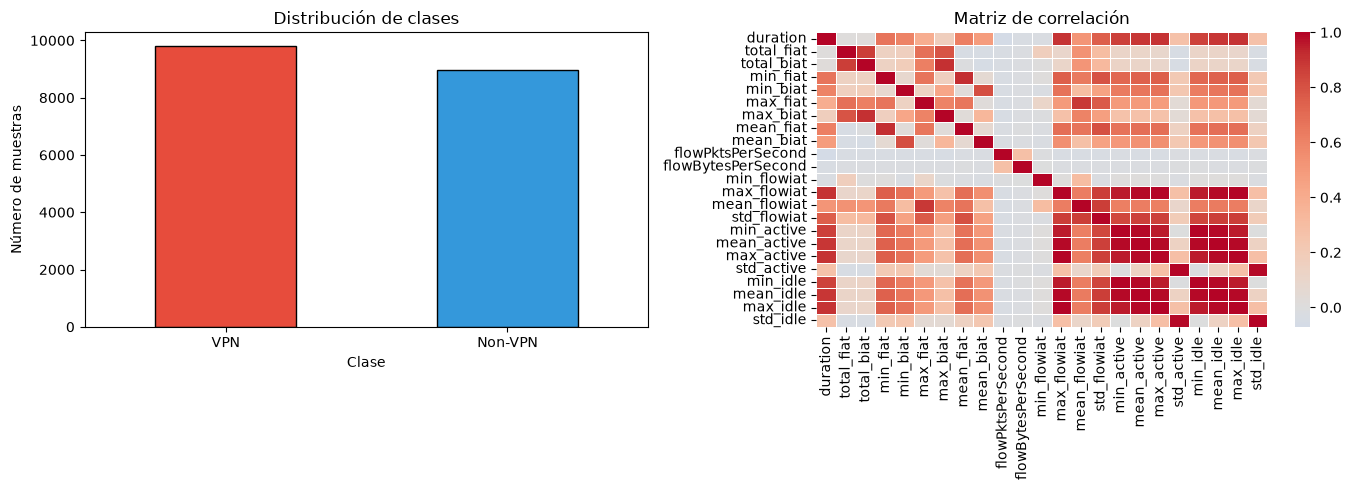

Guardado en results/eda_overview.png


In [10]:
# Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
df['class1'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#3498db'], edgecolor='black')
axes[0].set_title('Distribución de clases')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Número de muestras')
axes[0].tick_params(axis='x', rotation=0)

# Correlación entre features
corr = df.drop(columns='class1').corr()
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', center=0, linewidths=0.5)
axes[1].set_title('Matriz de correlación')

plt.tight_layout()
plt.savefig('../results/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado en results/eda_overview.png")

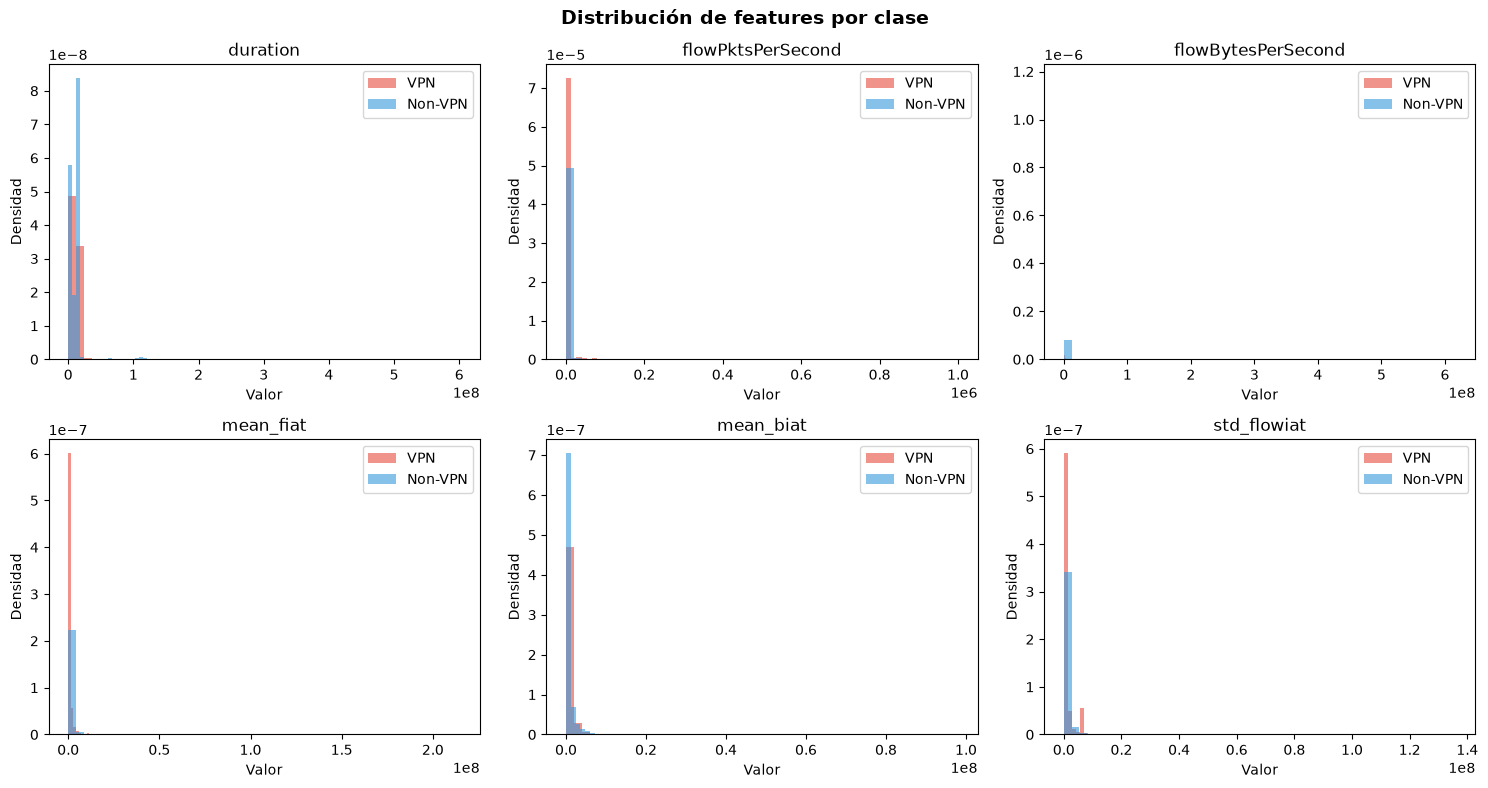

Guardado en results/feature_distributions.png


In [11]:
# Distribución de features clave por clase
features_to_plot = ['duration', 'flowPktsPerSecond', 'flowBytesPerSecond', 'mean_fiat', 'mean_biat', 'std_flowiat']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    vpn = df[df['class1'] == 'VPN'][feat]
    nonvpn = df[df['class1'] == 'Non-VPN'][feat]
    
    axes[i].hist(vpn, bins=50, alpha=0.6, color='#e74c3c', label='VPN', density=True)
    axes[i].hist(nonvpn, bins=50, alpha=0.6, color='#3498db', label='Non-VPN', density=True)
    axes[i].set_title(feat)
    axes[i].legend()
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Densidad')

plt.suptitle('Distribución de features por clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado en results/feature_distributions.png")